In [1]:
import matplotlib.pyplot as plt

In [2]:
import pandas as pd

In [3]:
import seaborn as sns

In [4]:
df=pd.read_csv("eda_manipulate_date_strings_with_python.csv")

In [5]:
df.head(10)

,date,number_of_strikes,center_point_geom
0,2016-08-05,16,POINT(-101.5 24.7)
1,2016-08-05,16,POINT(-85 34.3)
2,2016-08-05,16,POINT(-89 41.4)
3,2016-08-05,16,POINT(-89.8 30.7)
4,2016-08-05,16,POINT(-86.2 37.9)
5,2016-08-05,16,POINT(-97.8 38.9)
6,2016-08-05,16,POINT(-81.9 36)
7,2016-08-05,16,POINT(-90.9 36.7)
8,2016-08-05,16,POINT(-106.6 26.1)
9,2016-08-05,16,POINT(-108 31.6)


In [6]:
df['date']=pd.to_datetime(df['date'])

In [7]:
#creating four new columns week ,month ,quarter and year using strftime--> i.e string format time

In [8]:
# %Y for Year ,%v for week number and %q for quarter number

In [9]:
df['week']=df['date'].dt.strftime('%Y-W%V')

In [10]:
df['month']=df['date'].dt.strftime("%Y-%m")

In [11]:
df.head(2)

,date,number_of_strikes,center_point_geom,week,month
0,2016-08-05,16,POINT(-101.5 24.7),2016-W31,2016-08
1,2016-08-05,16,POINT(-85 34.3),2016-W31,2016-08


In [12]:
df['quarter']=df['date'].dt.to_period('Q').dt.strftime("%Y-Q%q")

In [13]:
df.head(1)

,date,number_of_strikes,center_point_geom,week,month,quarter
0,2016-08-05,16,POINT(-101.5 24.7),2016-W31,2016-08,2016-Q3


In [14]:
df['Year']=df['date'].dt.strftime("%Y")

In [15]:
df.head(1)

,date,number_of_strikes,center_point_geom,week,month,quarter,Year
0,2016-08-05,16,POINT(-101.5 24.7),2016-W31,2016-08,2016-Q3,2016


In [16]:
df.head(10)

,date,number_of_strikes,center_point_geom,week,month,quarter,Year
0,2016-08-05,16,POINT(-101.5 24.7),2016-W31,2016-08,2016-Q3,2016
1,2016-08-05,16,POINT(-85 34.3),2016-W31,2016-08,2016-Q3,2016
2,2016-08-05,16,POINT(-89 41.4),2016-W31,2016-08,2016-Q3,2016
3,2016-08-05,16,POINT(-89.8 30.7),2016-W31,2016-08,2016-Q3,2016
4,2016-08-05,16,POINT(-86.2 37.9),2016-W31,2016-08,2016-Q3,2016
5,2016-08-05,16,POINT(-97.8 38.9),2016-W31,2016-08,2016-Q3,2016
6,2016-08-05,16,POINT(-81.9 36),2016-W31,2016-08,2016-Q3,2016
7,2016-08-05,16,POINT(-90.9 36.7),2016-W31,2016-08,2016-Q3,2016
8,2016-08-05,16,POINT(-106.6 26.1),2016-W31,2016-08,2016-Q3,2016
9,2016-08-05,16,POINT(-108 31.6),2016-W31,2016-08,2016-Q3,2016


In [17]:
# Plot the weekely lightnings in 2018

In [18]:
# df['weekely_strikes']=df.loc[df['Year']==2018,df['number_of_strikes']]

In [19]:
# create a column for number of weekely lightning strikes in year 2018

In [20]:
# so here we have to first find out the strikes in 2018 weekely a

In [21]:
# After that no.of.weekely lightning strikes=sum of weekely strikes

In [22]:
# so we have to use groupy for aggregation and sum operatoras well

In [26]:
df_by_week_2018=df[df['Year']=='2018'].groupby(['week']).sum().reset_index()

In [27]:
df_by_week_2018=df[df['Year']=='2018'].groupby(['week']).sum().reset_index()

In [28]:
df_by_week_2018.head(3)

,week,number_of_strikes
0,2018-W01,34843
1,2018-W02,353425
2,2018-W03,37132


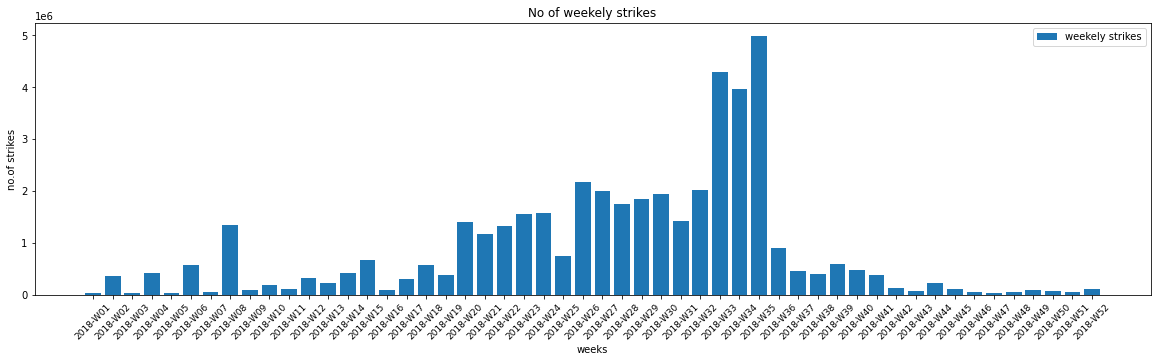

In [53]:
plt.figure(figsize=(20,5))    #This is used directly to increase the size of the output figure 
plt.bar(x=df_by_week_2018['week'],height=df_by_week_2018['number_of_strikes'],label='weekely strikes')
plt.plot
plt.xlabel("weeks")
plt.ylabel("no.of strikes")
plt.title("No of weekely strikes")
plt.xticks(rotation=45,fontsize=9)
plt.legend()
plt.show()